In [1]:
# import modules
import os
import pandas as pd
import pickle
import shap
import numpy as np
import scipy.stats as stats

# import visualization modules
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cwd = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(cwd, "..", ".."))

# build paths inside the repo
get_data_path = lambda folders, fname: os.path.normpath(
    os.path.join(BASE_DIR, *folders, fname)
)

# breast cancer cell lines
breast_cancer_path = get_data_path(['data', 'output', 'breast_cancer'], 'paralog_pairs_breast_cancer_df_fully_annotated_with_essentials.parquet')

# models
file_RF_model_contextualized = get_data_path(['data', 'output', 'models'], 'contextualised_model.pickle')
file_RF_model_full = get_data_path(['data', 'output', 'models'], 'full_model.pickle')

figure_path_box_plot_her = get_data_path(['figures'], 'box_plots_her_mutated.png')


In [3]:
breast_cancer_df = pd.read_parquet(breast_cancer_path)
breast_cancer_df = breast_cancer_df.rename(columns={'smallest_CC_GO_expression': 'go_CC_expression'})
breast_cancer_df[:3]

,prediction_rank,prediction_percentile,old_genepair,genepair,A1,A2,A1_entrez,A2_entrez,A1_ensembl,A2_ensembl,...,smallest_BP_GO_expression,smallest_CC_GO_essentiality,A1_rank,zA1_rank,A2_rank,zA2_rank,max_ranked_A1A2,min_ranked_A1A2,z_max_ranked_A1A2,z_min_ranked_A1A2
0,1,0.1,SMARCA2_SMARCA4,SMARCA2_SMARCA4,SMARCA2,SMARCA4,6595,6597,ENSG00000080503,ENSG00000127616,...,4.265264,5189.875,14677.0,0.656169,491.0,-0.947882,14677.0,491.0,0.656169,-0.947882
1,1,0.1,SMARCA2_SMARCA4,SMARCA2_SMARCA4,SMARCA2,SMARCA4,6595,6597,ENSG00000080503,ENSG00000127616,...,4.535862,7734.375,15721.0,0.913013,1854.0,-0.614466,15721.0,1854.0,0.913013,-0.614466
2,1,0.1,SMARCA2_SMARCA4,SMARCA2_SMARCA4,SMARCA2,SMARCA4,6595,6597,ENSG00000080503,ENSG00000127616,...,4.881678,8400.250,14888.0,0.708079,7562.0,0.781824,14888.0,7562.0,0.781824,0.708079


In [4]:
breast_cancer_df.genepair.nunique(), breast_cancer_df.shape[0]

(33574, 1510830)

In [5]:
feature_columns_1 = ['rMaxExp_A1A2', 'rMinExp_A1A2',
                     'max_ranked_A1A2', 'min_ranked_A1A2',
                     'max_cn', 'min_cn', 'Protein_Altering', 'Damaging', 
                     'min_sequence_identity',
                     'prediction_score', 
                     'weighted_PPI_essentiality', 'weighted_PPI_expression',
                     'smallest_BP_GO_essentiality', 'smallest_CC_GO_essentiality',
                     'smallest_BP_GO_expression', 'go_CC_expression'
                     ]

#target_column = 'SL_08'

print('num of features:', len(feature_columns_1))

num of features: 16


In [6]:
feature_columns_2 = feature_columns_1 + ['closest', 'WGD', 'family_size',
                                         'cds_length_ratio', 'shared_domains', 'has_pombe_ortholog',
                                         'has_essential_pombe_ortholog', 'has_cerevisiae_ortholog',
                                         'has_essential_cerevisiae_ortholog', 'conservation_score', 'mean_age',
                                         'either_in_complex', 'mean_complex_essentiality', 'colocalisation',
                                         'interact', 'n_total_ppi', 'fet_ppi_overlap',
                                         'gtex_spearman_corr', 'gtex_min_mean_expr', 'gtex_max_mean_expr']
feature_columns_2.remove('prediction_score')
print('num of features:', len(feature_columns_2))

num of features: 35


In [7]:
breast_cancer_df[feature_columns_1].isna().sum()

rMaxExp_A1A2                   0
rMinExp_A1A2                   0
max_ranked_A1A2                0
min_ranked_A1A2                0
max_cn                         0
min_cn                         0
Protein_Altering               0
Damaging                       0
min_sequence_identity          0
prediction_score               0
weighted_PPI_essentiality      0
weighted_PPI_expression        0
smallest_BP_GO_essentiality    0
smallest_CC_GO_essentiality    0
smallest_BP_GO_expression      0
go_CC_expression               0
dtype: int64

In [8]:
# Load RF classifier from file
with open(file_RF_model_contextualized, 'rb') as file:
    contextualized = pickle.load(file)

In [9]:
# predicitons for all ~36.6k paralog pairs
ypred_contextualized = contextualized.predict_proba(breast_cancer_df[feature_columns_1])[:,1]
all_predictions = breast_cancer_df.assign(contextualized_prediction_score=ypred_contextualized)

In [10]:
# Load RF classifier from file
with open(file_RF_model_full, 'rb') as file:
    full = pickle.load(file)

In [11]:
# predicitons for all ~36.6k paralog pairs
ypred_full = full.predict_proba(breast_cancer_df[feature_columns_2])[:,1]
all_predictions = all_predictions.assign(full_prediction_score=ypred_full)

In [12]:
all_predictions = all_predictions.sort_values(['full_prediction_score', 'contextualized_prediction_score'], ascending=False)
all_predictions.head()

,prediction_rank,prediction_percentile,old_genepair,genepair,A1,A2,A1_entrez,A2_entrez,A1_ensembl,A2_ensembl,...,A1_rank,zA1_rank,A2_rank,zA2_rank,max_ranked_A1A2,min_ranked_A1A2,z_max_ranked_A1A2,z_min_ranked_A1A2,contextualized_prediction_score,full_prediction_score
271,7,0.1,HDAC1_HDAC2,HDAC1_HDAC2,HDAC1,HDAC2,3065,3066,ENSG00000116478,ENSG00000196591,...,3368.0,-0.886165,9660.0,-0.164687,9660.0,3368.0,-0.164687,-0.886165,0.777927,0.864835
313,7,0.1,HDAC1_HDAC2,HDAC1_HDAC2,HDAC1,HDAC2,3065,3066,ENSG00000116478,ENSG00000196591,...,5537.0,-0.276839,8586.0,-0.414039,8586.0,5537.0,-0.276839,-0.414039,0.765877,0.861404
279,7,0.1,HDAC1_HDAC2,HDAC1_HDAC2,HDAC1,HDAC2,3065,3066,ENSG00000116478,ENSG00000196591,...,8400.0,0.527449,6492.0,-0.900207,8400.0,6492.0,0.527449,-0.900207,0.785032,0.858368
275,7,0.1,HDAC1_HDAC2,HDAC1_HDAC2,HDAC1,HDAC2,3065,3066,ENSG00000116478,ENSG00000196591,...,3660.0,-0.804135,11951.0,0.367219,11951.0,3660.0,0.367219,-0.804135,0.743945,0.849749
314,7,0.1,HDAC1_HDAC2,HDAC1_HDAC2,HDAC1,HDAC2,3065,3066,ENSG00000116478,ENSG00000196591,...,6025.0,-0.139748,10167.0,-0.046976,10167.0,6025.0,-0.046976,-0.139748,0.738572,0.844294


In [13]:
all_predictions_her_labeled = all_predictions.copy()
all_predictions_her_labeled = all_predictions_her_labeled.assign(
    mut_binary=all_predictions_her_labeled['consensus_her2_status'].map({
        'Negative': 0,
        'Positive': 1,
        'Unknown': np.nan
    })
)

all_predictions_her_labeled['mut_binary'].value_counts()

mut_binary
0.0    1074368
1.0     335740
Name: count, dtype: int64

In [ ]:
pairs_for_shap = ['EGFR_ERBB2', 
                  'ERBB2_ERBB3', 
                  'AKT1_AKT2', 
                  'TRAF3_TRAF4', 
                  'AP1G1_AP1G2', 
                  'ASF1A_ASF1B', 
                  'SAR1A_SAR1B', 
                  'GRHL1_GRHL2', 
                  'MYB_MYBL2' 
]

pairs_for_shap_df = all_predictions_her_labeled.loc[all_predictions_her_labeled['genepair'].isin(pairs_for_shap)]

pairs_for_shap_path = get_data_path(['data', 'output', 'breast_cancer'], 'pairs_for_shap.csv')
pairs_for_shap_df.to_csv(pairs_for_shap_path, index=False)
print(f"Saved: {pairs_for_shap_path}  shape={pairs_for_shap_df.shape}")

# Box Plots

In [15]:
def draw_signif_line(ax, x0, x1, y, pval, hd=20):
    """Draws a significance line between two box plots."""
    h = y / hd
    if pval < 0.0001: 
        text = '$p$=%.1e' % pval
    else: 
        text = '$p$=%.4f' % pval
    ax.plot([x0, x0, x1, x1], [y + h, y + 2 * h, y + 2 * h, y + h], lw=0.8, c='#666')
    ax.text((x0 + x1) * .5, y + 2.5 * h, text, ha='center', va='bottom', color='#666', fontsize=9)

In [16]:
def compute_upper_whisker(df, feature):
    """Computes the upper whisker of a box plot for a given feature."""
    Q1 = df[feature].quantile(q=0.25)
    Q3 = df[feature].quantile(q=0.75)
    IQR = Q3 - Q1
    return df[df[feature] <= (Q3 + 1.5 * IQR)][feature].max()

In [21]:
def draw_cont_graph(df, feature, ax, label=None, fliers=True, show_points=True, draw_signif=True, hd=20, xticklabels=None):

    my_pal = {1: "#BBBBBB", 0: "#56B4E9"}

    # Calculate the counts of SL and not_SL
    mutated = (df['mut_binary'] == 1).sum()
    not_mutated = (df['mut_binary'] == 0).sum()

    sns.despine(top=True, right=True, left=False, bottom=False)
    sns.boxplot(y=feature, x='mut_binary', hue='mut_binary', data=df, ax=ax, linewidth=0.8, saturation=0.8,
                showfliers=False, showmeans=False, palette=my_pal, order=[0, 1],
                medianprops={'color':'black', 'linewidth':0.8},
                boxprops={'edgecolor':'black', 'alpha':0.85})

    ax.set_ylabel(label if label else feature, fontsize=12)
    ax.set_xlabel('')
    ax.set_xticks([0, 1])

    if xticklabels is None:
        xticklabels = [f'WT \n(n={not_mutated})', f'M \n(n={mutated})']

    ax.set_xticklabels(xticklabels, fontsize=12)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    ax.legend().remove()

    if draw_signif:
        # Welch's t-test (unequal variances)
        pval = stats.ttest_ind(
            df.loc[df['mut_binary'] == 1, feature],
            df.loc[df['mut_binary'] == 0, feature],
            equal_var=False,
            nan_policy='omit'
        )[1]
        upper_whisker = max(
            compute_upper_whisker(df.loc[df['mut_binary'] == 1], feature),
            compute_upper_whisker(df.loc[df['mut_binary'] == 0], feature)
        )
        draw_signif_line(ax, 0, 1, upper_whisker + 0.05, pval, hd)


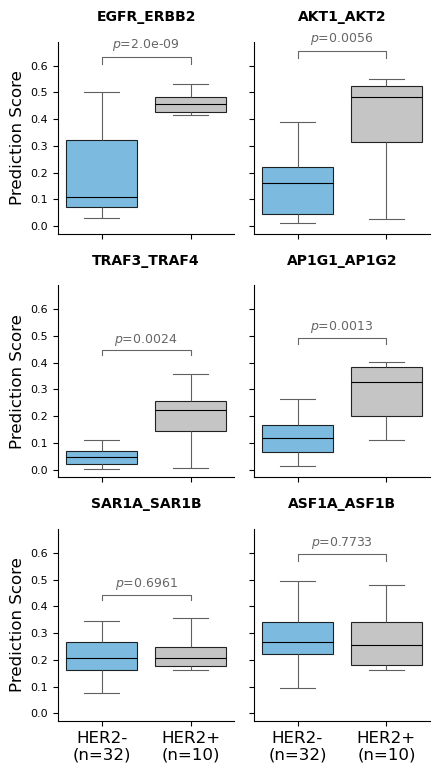

In [22]:
selected_genepairs = ['EGFR_ERBB2', 'AKT1_AKT2', 'TRAF3_TRAF4', 'AP1G1_AP1G2', 'SAR1A_SAR1B', 'ASF1A_ASF1B']

fig, axes = plt.subplots(3, 2, figsize=(4.5, 9), sharey=True, sharex=True)

for i, gene_pair in enumerate(selected_genepairs):
    # Get the current axis
    ax = axes[i // 2, i % 2]
    # Filter data for this gene pair
    df = all_predictions_her_labeled[all_predictions_her_labeled['genepair'] == gene_pair].copy()
    df = df.dropna(axis=0, how='any', subset=['mut_binary']).reset_index(drop=True)
    df['mut_binary'] = df['mut_binary'].astype(int)
    
    if len(df) > 0:
        n_her_neg = (df['mut_binary'] == 0).sum()
        n_her_pos = (df['mut_binary'] == 1).sum()
        
        if n_her_neg > 0 and n_her_pos > 0:
            # Create box plot for this gene pair
            xticklabels = [f'HER2-\n(n={n_her_neg})', f'HER2+\n(n={n_her_pos})']
            draw_cont_graph(df, 'full_prediction_score', ax,
                           label='Prediction Score',
                           xticklabels=xticklabels,
                           draw_signif=True, hd=22)
            
            ax.set_title(gene_pair, fontsize=10, fontweight='bold', pad=15)
        else:
            ax.text(0.5, 0.5, f'{gene_pair}\nInsufficient data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
    else:
        ax.text(0.5, 0.5, f'{gene_pair}\nNo data', 
               ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

# Hide the last unused subplot (position [1,3])
#axes[1, 3].set_visible(False)

# Add overall title and layout
plt.tight_layout(rect=[0, 0.03, 1, 0.90])

# Save combined plot
#combined_output_path = get_data_path(['figures'], 'box_plots_her_combined_full_scores_v3.png')
#plt.savefig(combined_output_path, dpi=500, bbox_inches='tight')
plt.show()